In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

In [2]:
mlflow.set_tracking_uri("http://localhost:5001")
mlflow.set_experiment("flight_delay_base")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1786818152302, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1786818152302, lifecycle_stage='active', name='flight_delay_base', tags={}, trace_location=None, workspace='default'>

In [4]:
%pwd

'/Users/nicholasstanfield/Desktop/flight-delay/notebooks'

In [2]:
df = pd.read_csv("../data/processed/flight_weather_data_2025.csv")
df.head()

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,ORIGIN,DEST,CRS_ELAPSED_TIME,DISTANCE,AIRLINE,ROUTE,DELAY,...,ARR_TEMPERATURE,ARR_PRECIPITATION,ARR_SNOWFALL,ARR_SNOW_DEPTH,ARR_VISIBILITY,ARR_SURFACE_PRESSURE,ARR_WIND_SPEED,ARR_WIND_GUSTS,DEP_HOUR,ARR_HOUR
0,1,1,3,AUS,ORD,165.0,977.0,American Airlines Inc.,AUS-ORD,0,...,-1.6,0.0,0.0,0.00,24700.0,991.8,20.9,37.4,5,8
1,1,7,2,PBI,DFW,202.0,1102.0,American Airlines Inc.,PBI-DFW,0,...,-3.4,0.0,0.0,0.00,24900.0,1009.6,15.5,20.2,6,8
2,1,26,7,LAS,DEN,119.0,628.0,United Air Lines Inc.,LAS-DEN,0,...,-7.8,0.0,0.0,0.04,13800.0,834.4,9.7,12.6,9,12
3,1,17,5,ICT,ATL,135.0,782.0,Delta Air Lines Inc.,ICT-ATL,0,...,9.5,0.0,0.0,0.00,54200.0,979.7,2.4,16.6,17,21
4,1,14,2,CHS,EWR,119.0,628.0,United Air Lines Inc.,CHS-EWR,0,...,-2.7,0.0,0.0,0.00,47500.0,1017.2,18.0,36.7,19,21


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359999 entries, 0 to 359998
Data columns (total 32 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   MONTH                 359999 non-null  int64  
 1   DAY_OF_MONTH          359999 non-null  int64  
 2   DAY_OF_WEEK           359999 non-null  int64  
 3   ORIGIN                359999 non-null  object 
 4   DEST                  359999 non-null  object 
 5   CRS_ELAPSED_TIME      359999 non-null  float64
 6   DISTANCE              359999 non-null  float64
 7   AIRLINE               359999 non-null  object 
 8   ROUTE                 359999 non-null  object 
 9   DELAY                 359999 non-null  int64  
 10  ORIGIN_LATITUDE       359999 non-null  float64
 11  ORIGIN_LONGITUDE      359999 non-null  float64
 12  DEST_LATITUDE         359999 non-null  float64
 13  DEST_LONGITUDE        359999 non-null  float64
 14  DEP_TEMPERATURE       359999 non-null  float64
 15  

In [9]:
df.describe().astype(int)

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,CRS_ELAPSED_TIME,DISTANCE,DELAY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DEST_LATITUDE,DEST_LONGITUDE,...,ARR_TEMPERATURE,ARR_PRECIPITATION,ARR_SNOWFALL,ARR_SNOW_DEPTH,ARR_VISIBILITY,ARR_SURFACE_PRESSURE,ARR_WIND_SPEED,ARR_WIND_GUSTS,DEP_HOUR,ARR_HOUR
count,359999,359999,359999,359999,359999,359999,359999,359999,359999,359999,...,359999,359999,359999,359999,359999,359999,359999,359999,359999,359999
mean,6,15,3,149,846,0,36,-95,36,-95,...,17,0,0,0,33170,985,11,20,12,14
std,3,8,2,73,602,0,6,18,6,18,...,10,1,0,0,20593,48,6,12,4,5
min,1,1,1,20,31,0,-14,-176,-14,-176,...,-39,0,0,0,0,749,0,0,0,0
25%,3,8,2,95,404,0,32,-111,32,-111,...,10,0,0,0,18200,983,5,11,9,11
50%,6,16,4,133,694,0,37,-89,37,-89,...,18,0,0,0,26800,998,9,18,13,15
75%,9,23,6,180,1081,0,40,-81,40,-81,...,25,0,0,0,43000,1014,14,27,17,19
max,12,31,7,694,5095,1,71,145,71,145,...,47,159,3,0,95120,1043,63,113,23,23


In [3]:
X = df.drop("DELAY", axis=1)
y = df["DELAY"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, stratify=y, random_state=42)

X_train.shape, X_test.shape

((287999, 31), (72000, 31))

In [5]:
categorical_columns = X_train.select_dtypes(include=["object"]).columns.to_list()

numeric_columns = X_train.select_dtypes(include=["int","float"]).columns.to_list()

In [14]:
categorical_columns

['ORIGIN', 'DEST', 'AIRLINE', 'ROUTE']

In [15]:
numeric_columns

['MONTH',
 'DAY_OF_MONTH',
 'DAY_OF_WEEK',
 'CRS_ELAPSED_TIME',
 'DISTANCE',
 'ORIGIN_LATITUDE',
 'ORIGIN_LONGITUDE',
 'DEST_LATITUDE',
 'DEST_LONGITUDE',
 'DEP_TEMPERATURE',
 'DEP_PRECIPITATION',
 'DEP_SNOWFALL',
 'DEP_SNOW_DEPTH',
 'DEP_VISIBILITY',
 'DEP_SURFACE_PRESSURE',
 'DEP_WIND_SPEED',
 'DEP_WIND_GUSTS',
 'ARR_TEMPERATURE',
 'ARR_PRECIPITATION',
 'ARR_SNOWFALL',
 'ARR_SNOW_DEPTH',
 'ARR_VISIBILITY',
 'ARR_SURFACE_PRESSURE',
 'ARR_WIND_SPEED',
 'ARR_WIND_GUSTS',
 'DEP_HOUR',
 'ARR_HOUR']

In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import  ColumnTransformer

num_pipeline = make_pipeline(StandardScaler())
cat_pipeline = make_pipeline(OneHotEncoder(handle_unknown='ignore'))


preprocessing = ColumnTransformer([
    ('num', num_pipeline, numeric_columns),
    ('cat', cat_pipeline, categorical_columns)
])

In [23]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
import mlflow.sklearn

mlflow.sklearn.autolog()

dummy = make_pipeline(preprocessing, DummyClassifier())

scoring = {"accuracy":"accuracy", 
           "precision":make_scorer(precision_score, zero_division=0),
           "recall":make_scorer(recall_score, zero_division=0),
           "f1":make_scorer(f1_score, zero_division=0)
          }

with mlflow.start_run(run_name="dummy_classifer_weather"):
    
    cv_results = cross_validate(dummy, X_train, y_train, cv=5, scoring=scoring, n_jobs=-1)

    metrics = {"cv_accuracy_mean": round(cv_results["test_accuracy"].mean(), 2),
               "cv_precision_mean": round(cv_results["test_precision"].mean(), 2),
               "cv_recall_mean": round(cv_results["test_recall"].mean(), 2),
               "cv_f1_mean": round(cv_results["test_f1"].mean(), 2),
              }

    mlflow.log_metrics(metrics)

print(metrics)

🏃 View run dummy_classifer_weather at: http://localhost:5001/#/experiments/1/runs/ebf12bab85b74b5ea94fcab1cd2f9786
🧪 View experiment at: http://localhost:5001/#/experiments/1
{'cv_accuracy_mean': np.float64(0.78), 'cv_precision_mean': np.float64(0.0), 'cv_recall_mean': np.float64(0.0), 'cv_f1_mean': np.float64(0.0)}


In [25]:
from sklearn.linear_model import LogisticRegression

log_model = make_pipeline(preprocessing, LogisticRegression(max_iter=5000))

with mlflow.start_run(run_name="logistic_regression_weather"):
    
    cv_results = cross_validate(log_model, X_train, y_train, cv=5, scoring=scoring, n_jobs=-1)

    metrics = {"cv_accuracy_mean": round(cv_results["test_accuracy"].mean(), 2),
               "cv_precision_mean": round(cv_results["test_precision"].mean(), 2),
               "cv_recall_mean": round(cv_results["test_recall"].mean(), 2),
               "cv_f1_mean": round(cv_results["test_f1"].mean(), 2),
              }

    mlflow.log_metrics(metrics)

print(metrics)    

🏃 View run logistic_regression_weather at: http://localhost:5001/#/experiments/1/runs/bb645ae0207243888d0bb4a1d5a8c948
🧪 View experiment at: http://localhost:5001/#/experiments/1
{'cv_accuracy_mean': np.float64(0.78), 'cv_precision_mean': np.float64(0.53), 'cv_recall_mean': np.float64(0.07), 'cv_f1_mean': np.float64(0.13)}


In [26]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = make_pipeline(
    preprocessing,
    DecisionTreeClassifier(random_state=42)
)

with mlflow.start_run(run_name="decision_tree_weather"):

    cv_results = cross_validate(
        decision_tree,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    metrics = {
    "cv_accuracy_mean": round(cv_results["test_accuracy"].mean(), 2),
    "cv_precision_mean": round(cv_results["test_precision"].mean(), 2),
    "cv_recall_mean": round(cv_results["test_recall"].mean(), 2),
    "cv_f1_mean": round(cv_results["test_f1"].mean(), 2),
    }

    mlflow.log_metrics(metrics)

metrics

🏃 View run decision_tree_weather at: http://localhost:5001/#/experiments/1/runs/a7783f7a2c3a49d281a41696d0b3b1ab
🧪 View experiment at: http://localhost:5001/#/experiments/1


{'cv_accuracy_mean': np.float64(0.71),
 'cv_precision_mean': np.float64(0.33),
 'cv_recall_mean': np.float64(0.31),
 'cv_f1_mean': np.float64(0.32)}

In [27]:
from sklearn.ensemble import RandomForestClassifier

random_forest = make_pipeline(
    preprocessing,
    RandomForestClassifier(
        random_state=42
    )
)

with mlflow.start_run(run_name="random_forest"):

    cv_results = cross_validate(
        random_forest,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    metrics = {
        "cv_accuracy_mean": round(cv_results["test_accuracy"].mean(), 2),
        "cv_precision_mean": round(cv_results["test_precision"].mean(), 2),
        "cv_recall_mean": round(cv_results["test_recall"].mean(), 2),
        "cv_f1_mean": round(cv_results["test_f1"].mean(), 2),
    }

    mlflow.log_metrics(metrics)

metrics

🏃 View run random_forest at: http://localhost:5001/#/experiments/1/runs/eed8892d44f04f2fa3f76ecde55c745c
🧪 View experiment at: http://localhost:5001/#/experiments/1


{'cv_accuracy_mean': np.float64(0.78),
 'cv_precision_mean': np.float64(0.69),
 'cv_recall_mean': np.float64(0.06),
 'cv_f1_mean': np.float64(0.11)}

In [30]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline

cat_pipeline = Pipeline([("one_hot_encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
num_pipeline = Pipeline([("scale", StandardScaler())])


preprocessing = ColumnTransformer([
    ("num", num_pipeline, numeric_columns),
    ("cat", cat_pipeline, categorical_columns),
])


hist_gradient_boosting = make_pipeline(
    preprocessing,
    HistGradientBoostingClassifier(
        random_state=42
    )
)


scoring = {"accuracy":"accuracy", 
           "precision":make_scorer(precision_score, zero_division=0),
           "recall":make_scorer(recall_score, zero_division=0),
           "f1":make_scorer(f1_score, zero_division=0),
           "roc_auc":"roc_auc"
          }

with mlflow.start_run(run_name="hist_gradient_boosting_weather"):

    cv_results = cross_validate(
        hist_gradient_boosting,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=1
    )

    metrics = {
        "cv_accuracy_mean": round(cv_results["test_accuracy"].mean(), 2),
        "cv_precision_mean": round(cv_results["test_precision"].mean(), 2),
        "cv_recall_mean": round(cv_results["test_recall"].mean(), 2),
        "cv_f1_mean": round(cv_results["test_f1"].mean(), 2),
    }

    mlflow.log_metrics(metrics)

metrics

🏃 View run hist_gradient_boosting_weather at: http://localhost:5001/#/experiments/1/runs/4e9018a61ab74c3295aa09c124b9909e
🧪 View experiment at: http://localhost:5001/#/experiments/1


{'cv_accuracy_mean': np.float64(0.79),
 'cv_precision_mean': np.float64(0.66),
 'cv_recall_mean': np.float64(0.13),
 'cv_f1_mean': np.float64(0.21)}

In [33]:
cv_results["test_roc_auc"].mean()

np.float64(0.7239757840642362)

In [36]:
from xgboost import XGBClassifier

cat_pipeline = Pipeline([("one_hot_encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
num_pipeline = Pipeline([("scale", StandardScaler())])

preprocessing = ColumnTransformer([
    ("num", num_pipeline, numeric_columns),
    ("cat", cat_pipeline, categorical_columns),
])

xgboost_classifier = make_pipeline(
    preprocessing,
    XGBClassifier(
        random_state=42,
        n_jobs=1,
        eval_metric="logloss"
    )
)

with mlflow.start_run(run_name="xgboost_classifier_weather"):

    cv_results = cross_validate(
        xgboost_classifier,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=1
    )

    metrics = {
        "cv_accuracy_mean": round(cv_results["test_accuracy"].mean(), 2),
        "cv_precision_mean": round(cv_results["test_precision"].mean(), 2),
        "cv_recall_mean": round(cv_results["test_recall"].mean(), 2),
        "cv_f1_mean": round(cv_results["test_f1"].mean(), 2),
        "cv_roc_auc": round(cv_results["test_roc_auc"].mean(), 2),
    }

    mlflow.log_metrics(metrics)

metrics

🏃 View run xgboost_classifier_weather at: http://localhost:5001/#/experiments/1/runs/6b388676c91f4acfae0d1e6094628ce0
🧪 View experiment at: http://localhost:5001/#/experiments/1


{'cv_accuracy_mean': np.float64(0.79),
 'cv_precision_mean': np.float64(0.63),
 'cv_recall_mean': np.float64(0.16),
 'cv_f1_mean': np.float64(0.72)}

In [38]:
cv_results

{'fit_time': array([184.62039399, 183.19509411, 186.86287785, 189.59027719,
        192.40202212]),
 'score_time': array([3.22412205, 3.08435297, 2.96979713, 3.2532568 , 3.29917288]),
 'test_accuracy': array([0.79152778, 0.79265625, 0.79348958, 0.79234375, 0.79124638]),
 'test_precision': array([0.62834138, 0.63502506, 0.63905868, 0.6277593 , 0.62019083]),
 'test_recall': array([0.15236236, 0.15829754, 0.16329559, 0.16211151, 0.15736041]),
 'test_f1': array([0.24525456, 0.25342252, 0.26012316, 0.25768013, 0.25102778]),
 'test_roc_auc': array([0.72422589, 0.72406663, 0.72165374, 0.72906907, 0.72250431])}

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import LearningCurveDisplay
from sklearn.pipeline import Pipeline

cat_pipeline = Pipeline([("one_hot_encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
num_pipeline = Pipeline([("scale", StandardScaler())])

preprocessing = ColumnTransformer([
    ("num", num_pipeline, numeric_columns),
    ("cat", cat_pipeline, categorical_columns),
])

xgboost_classifier = make_pipeline(
    preprocessing,
    XGBClassifier(
        random_state=42,
        n_jobs=1,
        eval_metric="logloss"
    )
)

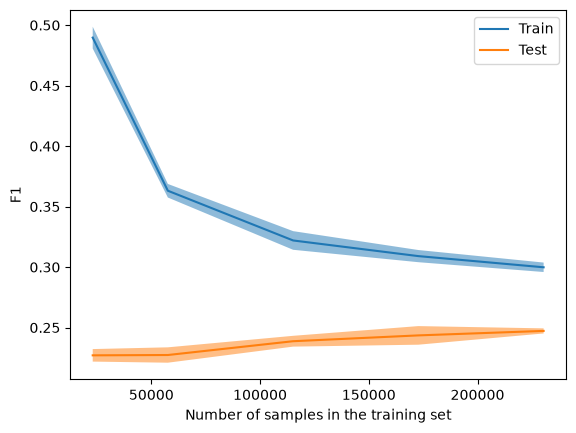

In [9]:
from sklearn.model_selection import (
    LearningCurveDisplay,
    StratifiedKFold
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

LearningCurveDisplay.from_estimator(
    xgboost_classifier,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0],
    shuffle=True,
    random_state=42,
    n_jobs=1
)

In [10]:
# there is room to increase the number of training samples, though with diminishing marginal returns

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform
from xgboost import XGBClassifier
from sklearn.model_selection import LearningCurveDisplay
from sklearn.pipeline import Pipeline

cat_pipeline = Pipeline([("one_hot_encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=True))])
num_pipeline = Pipeline([("scale", StandardScaler())])

preprocessing = ColumnTransformer([
    ("num", num_pipeline, numeric_columns),
    ("cat", cat_pipeline, categorical_columns),
])

xgboost_classifier = make_pipeline(
    preprocessing,
    XGBClassifier(
        random_state=42,
        n_jobs=1,
        eval_metric="logloss"
    )
)
param_distributions = {
    "xgbclassifier__n_estimators": randint(100, 1000),
    "xgbclassifier__max_depth": randint(2, 10),
    "xgbclassifier__learning_rate": loguniform(0.01, 0.3),
    "xgbclassifier__subsample": uniform(0.6, 0.4),
    "xgbclassifier__colsample_bytree": uniform(0.6, 0.4),
    "xgbclassifier__min_child_weight": randint(1, 10),
}

random_search = RandomizedSearchCV(
    estimator=xgboost_classifier,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=2,
    verbose=2,
    return_train_score=True
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'xgbclassifier__colsample_bytree': <scipy.stats....t 0x1463a3140>, 'xgbclassifier__learning_rate': <scipy.stats....t 0x1463a2450>, 'xgbclassifier__max_depth': <scipy.stats....t 0x1463a0ec0>, 'xgbclassifier__min_child_weight': <scipy.stats....t 0x1463a17f0>, ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the bes

[CV] END xgbclassifier__colsample_bytree=0.749816047538945, xgbclassifier__learning_rate=0.2536999076681772, xgbclassifier__max_depth=4, xgbclassifier__min_child_weight=8, xgbclassifier__n_estimators=800, xgbclassifier__subsample=0.8387400631785948; total time=   9.3s
[CV] END xgbclassifier__colsample_bytree=0.7783331011414365, xgbclassifier__learning_rate=0.014049959523783904, xgbclassifier__max_depth=4, xgbclassifier__min_child_weight=8, xgbclassifier__n_estimators=472, xgbclassifier__subsample=0.8404460046972835; total time=   7.4s
[CV] END xgbclassifier__colsample_bytree=0.7783331011414365, xgbclassifier__learning_rate=0.014049959523783904, xgbclassifier__max_depth=4, xgbclassifier__min_child_weight=8, xgbclassifier__n_estimators=472, xgbclassifier__subsample=0.8404460046972835; total time=   7.3s
[CV] END xgbclassifier__colsample_bytree=0.8832290311184181, xgbclassifier__learning_rate=0.010725209743171997, xgbclassifier__max_depth=3, xgbclassifier__min_child_weight=8, xgbclassifie

In [13]:
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_xgbclassifier__colsample_bytree,param_xgbclassifier__learning_rate,param_xgbclassifier__max_depth,param_xgbclassifier__min_child_weight,param_xgbclassifier__n_estimators,param_xgbclassifier__subsample,...,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
0,8.403050,0.319613,0.677941,0.004731,0.749816,0.253700,4,8,800,0.838740,...,0.290740,0.279174,0.286000,0.004947,2,0.353208,0.352567,0.357845,0.354540,0.002352
1,6.949179,0.049461,0.454490,0.005500,0.778333,0.014050,4,8,472,0.840446,...,0.092367,0.096662,0.095446,0.002193,8,0.099265,0.098372,0.107110,0.101583,0.003926
2,6.501873,0.134335,0.379604,0.007008,0.883229,0.010725,3,8,591,0.975421,...,0.056009,0.058583,0.057269,0.001052,9,0.059418,0.055974,0.064221,0.059871,0.003382
3,3.011406,0.025911,0.270411,0.001996,0.600312,0.292157,2,6,352,0.772778,...,0.180058,0.178900,0.182541,0.004356,5,0.192838,0.189489,0.197618,0.193315,0.003336
4,8.634590,0.084596,0.615729,0.006815,0.716492,0.080127,3,3,975,0.805694,...,0.198348,0.193063,0.198078,0.003989,4,0.218611,0.211892,0.223767,0.218090,0.004862
5,2.442404,0.056871,0.206647,0.002008,0.836966,0.011712,4,7,120,0.780200,...,0.013846,0.014123,0.013938,0.000131,10,0.016060,0.011585,0.015045,0.014230,0.001915
6,15.555653,0.842760,1.345909,0.006763,0.605306,0.246460,7,2,876,0.606387,...,0.328921,0.326812,0.327702,0.000892,1,0.599401,0.595720,0.604668,0.599930,0.003672
7,8.856949,0.049716,0.677241,0.004619,0.692358,0.022700,5,7,527,0.798071,...,0.174482,0.171980,0.174028,0.001521,6,0.191033,0.187102,0.197955,0.192030,0.004486
8,9.293938,0.202115,0.934050,0.014677,0.613755,0.220382,5,2,971,0.902145,...,0.288212,0.282204,0.282587,0.004446,3,0.376617,0.376091,0.385613,0.379441,0.004370
9,9.646312,0.237429,0.698207,0.010356,0.770062,0.020284,5,6,576,0.987834,...,0.170277,0.166988,0.170168,0.002553,7,0.185747,0.185205,0.194326,0.188426,0.004178


In [14]:
random_search.score(X_train, y_train)

0.5228704846760776

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform
from xgboost import XGBClassifier
from sklearn.model_selection import LearningCurveDisplay
from sklearn.pipeline import Pipeline

cat_pipeline = Pipeline([("one_hot_encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=True))])
num_pipeline = Pipeline([("scale", StandardScaler())])

preprocessing = ColumnTransformer([
    ("num", num_pipeline, numeric_columns),
    ("cat", cat_pipeline, categorical_columns),
])

xgboost_classifier = make_pipeline(
    preprocessing,
    XGBClassifier(
        random_state=42,
        n_jobs=1,
        eval_metric="logloss"
    )
)
param_distributions = {
    "xgbclassifier__n_estimators": randint(100, 1000),
    "xgbclassifier__max_depth": randint(2, 10),
    "xgbclassifier__learning_rate": loguniform(0.01, 0.3),
    "xgbclassifier__subsample": uniform(0.6, 0.4),
    "xgbclassifier__colsample_bytree": uniform(0.6, 0.4),
    "xgbclassifier__min_child_weight": randint(1, 10),
}

random_search = RandomizedSearchCV(
    estimator=xgboost_classifier,
    param_distributions=param_distributions,
    n_iter=100,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=2,
    verbose=2,
    return_train_score=True
)

random_search.fit(X_train, y_train)

In [16]:
print("Done")

Done


In [18]:
results = pd.DataFrame(random_search.cv_results_)
results = results.sort_values("rank_test_score")

In [22]:
results[["mean_test_score", "rank_test_score",'param_xgbclassifier__colsample_bytree',
       'param_xgbclassifier__learning_rate', 'param_xgbclassifier__max_depth',
       'param_xgbclassifier__min_child_weight',
       'param_xgbclassifier__n_estimators', 'param_xgbclassifier__subsample']].head()

,mean_test_score,rank_test_score,param_xgbclassifier__colsample_bytree,param_xgbclassifier__learning_rate,param_xgbclassifier__max_depth,param_xgbclassifier__min_child_weight,param_xgbclassifier__n_estimators,param_xgbclassifier__subsample
6,0.327702,1,0.605306,0.246460,7,2,876,0.606387
36,0.314442,2,0.816579,0.106600,8,9,671,0.704332
64,0.313911,3,0.819691,0.113644,9,5,996,0.981946
72,0.307111,4,0.850376,0.162881,9,2,352,0.637777
10,0.299649,5,0.910053,0.244205,7,4,369,0.890909


In [25]:
results.to_csv("/Users/nicholasstanfield/Desktop/xgboost_weather_results.csv",index=False)

In [26]:
plot_results = results.copy()

plot_results = plot_results.rename(columns={
    col: col.replace("param_xgbclassifier__", "")
    for col in plot_results.columns
    if col.startswith("param_xgbclassifier__")
})

plot_results["train_test_gap"] = (
    plot_results["mean_train_score"]
    - plot_results["mean_test_score"]
)

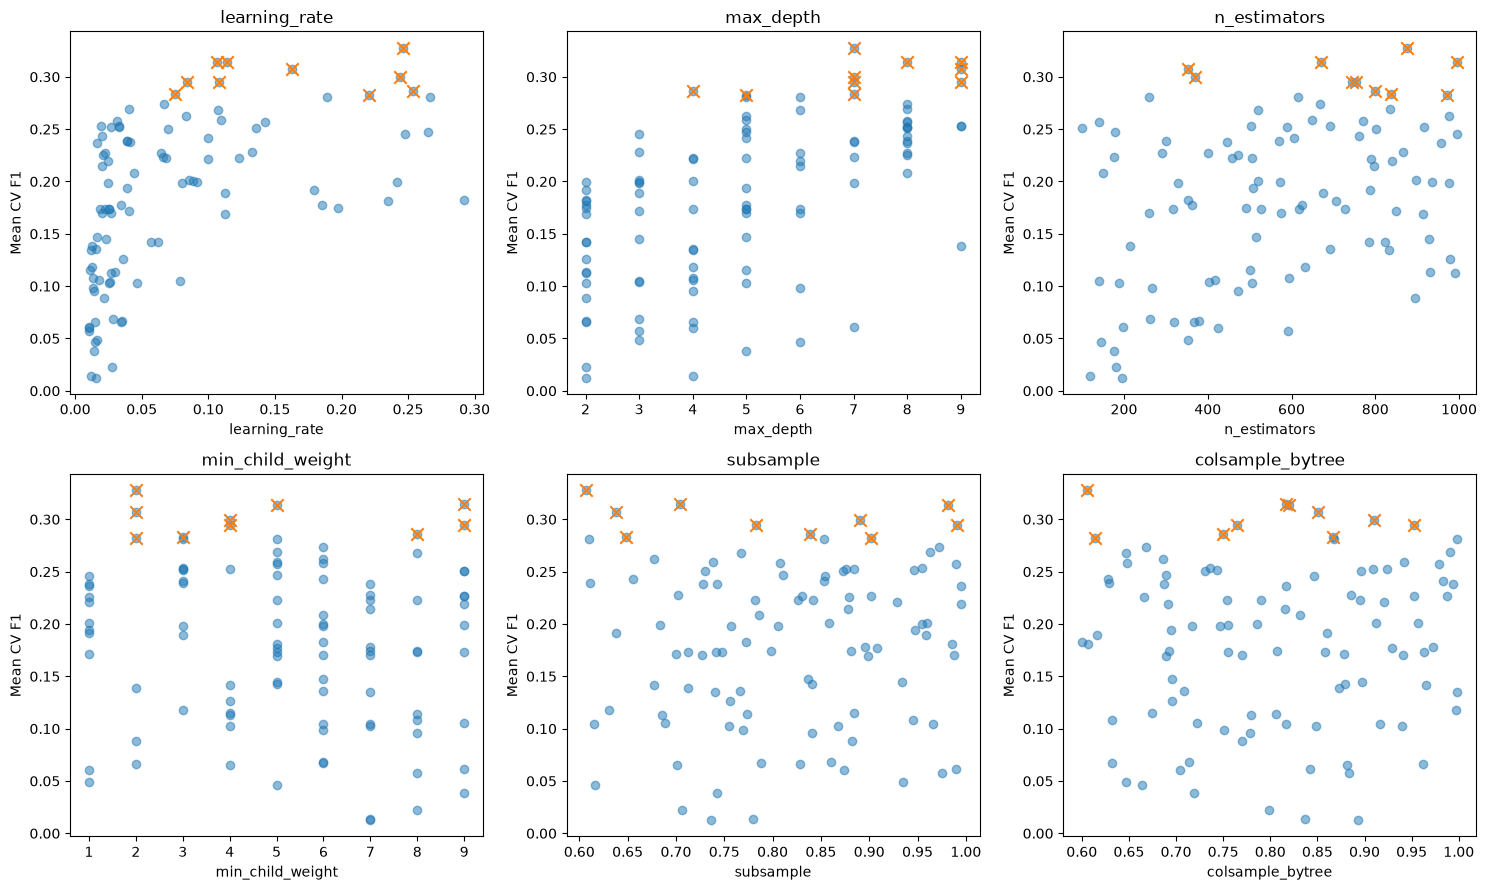

In [27]:
import matplotlib.pyplot as plt

params = [
    "learning_rate",
    "max_depth",
    "n_estimators",
    "min_child_weight",
    "subsample",
    "colsample_bytree",
]

top_10 = plot_results.nsmallest(10, "rank_test_score")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for param, ax in zip(params, axes.flatten()):

    ax.scatter(
        plot_results[param],
        plot_results["mean_test_score"],
        alpha=0.5,
        label="All trials"
    )

    ax.scatter(
        top_10[param],
        top_10["mean_test_score"],
        marker="x",
        s=80,
        label="Top 10"
    )

    ax.set_xlabel(param)
    ax.set_ylabel("Mean CV F1")
    ax.set_title(param)

plt.tight_layout()
plt.show()

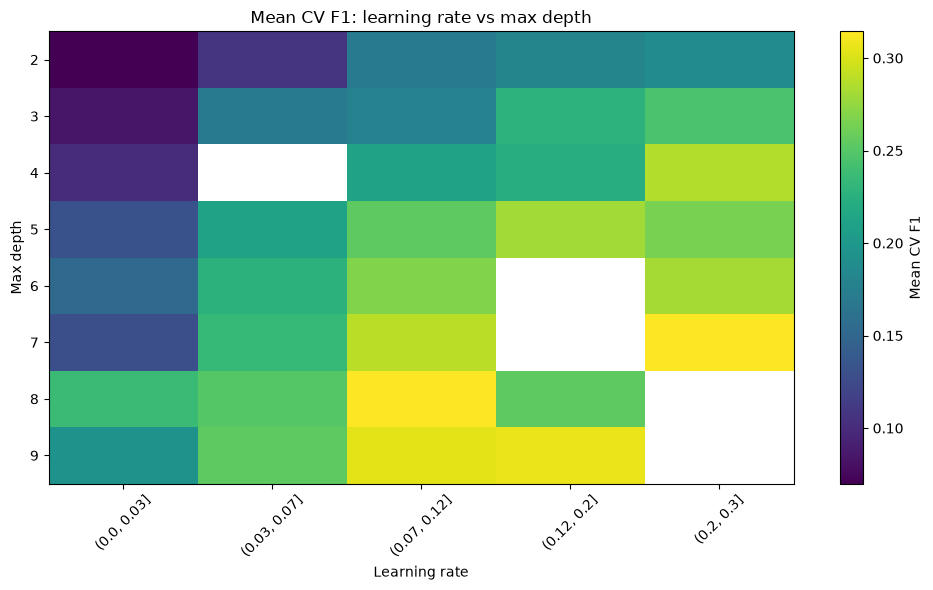

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

plot_results["learning_rate_bin"] = pd.cut(
    plot_results["learning_rate"],
    bins=[0, 0.03, 0.07, 0.12, 0.20, 0.30]
)

heatmap_data = plot_results.pivot_table(
    index="max_depth",
    columns="learning_rate_bin",
    values="mean_test_score",
    aggfunc="mean",
    observed=True
)

plt.figure(figsize=(10, 6))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.colorbar(label="Mean CV F1")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns.astype(str),
    rotation=45
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("Learning rate")
plt.ylabel("Max depth")
plt.title("Mean CV F1: learning rate vs max depth")

plt.tight_layout()
plt.show()

In [31]:
best_model = random_search.best_estimator_
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['MONTH','DAY_OF_MONTH','DAY_OF_WEEK',...,'ARR_WIND_GUSTS','DEP_HOUR', 'ARR_HOUR']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

In [32]:
%pwd

'/Users/nicholasstanfield/Desktop/flight-delay/notebooks'

In [34]:
import joblib

joblib.dump(best_model, "../models/xgboost_v1.joblib")

['../models/xgboost_v1.joblib']

In [36]:
model = joblib.load("../models/xgboost_v1.joblib")
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['MONTH','DAY_OF_MONTH','DAY_OF_WEEK',...,'ARR_WIND_GUSTS','DEP_HOUR', 'ARR_HOUR']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

In [40]:
model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(72000,))